# Predicting Match Outcomes in VCT 2026 Professional Valorant

## Introduction

The purpose of this project is to develop a model that will predict the percentage an Esports team will beat their match-up.

<div style="text-align: center;">
    <img src="1_logo.png" width="500">
</div>

## What Is Valorant?

Valorant is a team-based tactical first-person shooter developed by Riot Games, where two teams of five players compete across multiple maps to win rounds by eliminating opponents or completing objectives (planting/defusing a spike). Professional Valorant is organized through Riot's **VCT (Valorant Champions Tour)** system, which consists of regional leagues (Americas, EMEA, Pacific, China) and their international events. 

<div style="text-align: center;">
    <img src="2_stage.png" width="600">
    <p>VCT Stage</p>
</div>

## What Are We Trying To Do?

The question I'd like to pose is: "Can we accurately predict the outcome of a VCT Americas match. Specifically, which team will win based on team and player performance statistics?" It seems quite reasonable to hypothesize that a match's outcome would vary depending on individual performance metrics like Average Combat Score (ACS), kill-death ratio (KD), first kill rate, and clutch success rate, as well as team-level factors like recent form and map win rates. Coaching staffs and analysts in esports increasingly rely on data-driven insights to evaluate players and craft strategies, so understanding which metrics are most predictive of winning can inform roster decisions, in-game calling, and opponent scouting. So, I would like to test whether it is possible to develop a model that can predict VCT match winners based on those qualities.

<div style="text-align: center;">
    <img src="4_vcteams.webp" width="600">
    <p>2026 VCT Teams</p>
</div>

## Loading Packages and Data

Before any analysis can begin, we load all necessary libraries and read in our dataset. 

In [97]:
#---Core---
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#---Visualization---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

#---Preprocessing---
from sklearn.model_selection import (train_test_split, StratifiedKFold, 
                                    GridSearchCV, RandomizedSearchCV,
                                    cross_val_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#---Models---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

#---Evaluation---
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

#---Settings---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries imported successfully!")

All libraries imported successfully!


This data was taken from the Kaggle dataset, "Valorant Champion Tour 2021-2026 Data," compiled by user Ryan Luong. It contains official match, player, and team statistics from VCT tournaments spanning the 2021 through 2026 competitive seasons across all tournments. In this case however, I am prioritizing only 2026 data. This includes Kickoff, and Masters Santiago. 

## Tidying the Combined Data

In [98]:
#---Load Data---
df = pd.read_csv('combined_output.csv')

#---Basic Shape ---
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

#---Source Files Present---
print("\nUnique Source Files:")
print(df['_source_file'].value_counts())

#---Preview---
print("\nData Preview:")
print(df.head(10))

Shape: (136352, 101)

Column Names:
['Player', 'Player ID', '_source_file', 'Abbreviated', 'Full Name', 'Tournament', 'Stage', 'Match Type', 'Match Name', 'Map', 'Round Number', 'Team', 'Loadout Value', 'Remaining Credits', 'Type', 'Outcome', 'Tournament ID', 'Stage ID', 'Match Type ID', 'Agent', 'Total Wins By Map', 'Total Loss By Map', 'Total Maps Played', 'Team ID', 'Initiated', 'Won', 'Action', 'Pick Rate', 'Method', 'Agents', 'Rating', 'Average Combat Score', 'Kills', 'Deaths', 'Assists', 'Kills - Deaths (KD)', 'Kill, Assist, Trade, Survive %', 'Average Damage Per Round', 'Headshot %', 'First Kills', 'First Deaths', 'Kills - Deaths (FKD)', 'Side', 'Teams', 'Rounds Played', 'Kills:Deaths', 'Kills Per Round', 'Assists Per Round', 'First Kills Per Round', 'First Deaths Per Round', 'Clutch Success %', 'Clutches (won/played)', 'Maximum Kills in a Single Map', 'Team A', 'Team B', 'Team A Score', 'Team B Score', 'Match Result', 'Match ID', 'Game ID', 'Elimination', 'Detonated', 'Defused'

### Data Cleaning & Feature Engineering

The raw combined CSV contains data from multiple source files covering different aspects of VCT matches including players, teams, maps, and rounds. Before we can build any features, we first need to split this combined dataset back into its individual sub-dataframes 
based on the `_source_file` column. This gives us clean, purpose-specific tables that are easier to work with and join together in later steps.

In [99]:
# Split combined dataframe into individual source dataframes
source_files = df['_source_file'].unique()

# Create a dictionary to hold the individual dataframes
dfs = {source: df[df['_source_file'] == source].reset_index(drop=True) 
       for source in source_files}

# Preview the most important ones
for name in ['players_stats.csv', 'overview.csv', 'scores.csv',
             'maps_scores.csv', 'maps_stats.csv']:
    print(f"\n{'='*50}")
    print(f"SOURCE: {name}, SHAPE: {dfs[name].shape}")
    # Only show columns that are not all null
    non_null_cols = dfs[name].columns[dfs[name].notna().any()].tolist()
    print(f"Non-null columns: {non_null_cols}")
    print(dfs[name][non_null_cols].head(3))



SOURCE: players_stats.csv, SHAPE: (5231, 101)
Non-null columns: ['Player', '_source_file', 'Tournament', 'Stage', 'Match Type', 'Agents', 'Rating', 'Average Combat Score', 'Kills', 'Deaths', 'Assists', 'Kill, Assist, Trade, Survive %', 'Average Damage Per Round', 'Headshot %', 'First Kills', 'First Deaths', 'Teams', 'Rounds Played', 'Kills:Deaths', 'Kills Per Round', 'Assists Per Round', 'First Kills Per Round', 'First Deaths Per Round', 'Clutch Success %', 'Clutches (won/played)', 'Maximum Kills in a Single Map']
  Player       _source_file                      Tournament     Stage  \
0  skuba  players_stats.csv  Valorant Masters Santiago 2026  Playoffs   
1  skuba  players_stats.csv  Valorant Masters Santiago 2026  Playoffs   
2  skuba  players_stats.csv  Valorant Masters Santiago 2026  Playoffs   

            Match Type        Agents  Rating  Average Combat Score  Kills  \
0  Upper Quarterfinals         astra    1.93                 289.0   22.0   
1  Upper Quarterfinals         v

### Building the Match-Level Dataset

The raw data is recorded at the **player level**. One row per player per match. However, our prediction target is a **match outcome**, so we need to aggregate individual player statistics up to the team level for each match. 

For each team in each match, we compute the average of key performance metrics across all 5 players: Average Combat Score (ACS), Rating, Kill-Death Ratio (KD), Headshot Percentage, and First Kills. This gives us one row per team per match, capturing how the team collectively performed. This will be more meaningful for predicting match outcomes than any single player's stats alone.

In [100]:
# Isolate Player Stats for EDA
ps = dfs['players_stats.csv'].copy()

# Clean Percentage Columns -> Numeric
pct_cols = ['Kill, Assist, Trade, Survive %', 'Headshot %',
            'Clutch Success %']
for col in pct_cols:
    ps[col] = ps[col].astype(str).str.replace('%', '').str.strip()
    ps[col] = pd.to_numeric(ps[col], errors='coerce')

# Aggregate Stats per Team per Match
numeric_features = ['Rating', 'Average Combat Score', 'Kills', 'Deaths',
                    'Assists', 'Kill, Assist, Trade, Survive %',
                    'Average Damage Per Round', 'Headshot %',
                    'First Kills', 'First Deaths', 'Kills Per Round',
                    'Assists Per Round', 'First Kills Per Round',
                    'First Deaths Per Round', 'Clutch Success %']

team_match_stats = (
    ps.groupby(['Tournament', 'Stage', 'Match Type', 'Teams'])[numeric_features]
    .mean()
    .reset_index()
)

print("Team-match aggregated stats shape:", team_match_stats.shape)
print(team_match_stats.head())

Team-match aggregated stats shape: (349, 19)
                   Tournament       Stage       Match Type          Teams  \
0  VCT 2026: Americas Kickoff  All Stages  All Match Types    100 Thieves   
1  VCT 2026: Americas Kickoff  All Stages  All Match Types         Cloud9   
2  VCT 2026: Americas Kickoff  All Stages  All Match Types   Cloud9, ENVY   
3  VCT 2026: Americas Kickoff  All Stages  All Match Types           ENVY   
4  VCT 2026: Americas Kickoff  All Stages  All Match Types  Evil Geniuses   

     Rating  Average Combat Score       Kills  Deaths    Assists  \
0  1.022174            199.304348  132.695652  130.00  56.000000   
1  0.965667            187.900000   72.666667   73.60  34.133333   
2  1.048000            218.600000   56.800000   46.00  10.000000   
3  0.988000            193.750000   89.950000   91.85  33.050000   
4  0.968000            187.900000   86.500000   85.60  34.000000   

   Kill, Assist, Trade, Survive %  Average Damage Per Round  Headshot %  \
0       

In [101]:
# Isolate match results (target variable)
scores = dfs['scores.csv'].copy()
non_null_scores = scores.columns[scores.notna().any()].tolist()
print("\nscores.csv non-null columns:", non_null_scores)
print(scores[non_null_scores].head(10))


scores.csv non-null columns: ['_source_file', 'Tournament', 'Stage', 'Match Type', 'Match Name', 'Team A', 'Team B', 'Team A Score', 'Team B Score', 'Match Result']
  _source_file                      Tournament        Stage     Match Type  \
0   scores.csv  Valorant Masters Santiago 2026  Swiss Stage        Round 1   
1   scores.csv  Valorant Masters Santiago 2026  Swiss Stage        Round 1   
2   scores.csv  Valorant Masters Santiago 2026  Swiss Stage        Round 1   
3   scores.csv  Valorant Masters Santiago 2026  Swiss Stage        Round 1   
4   scores.csv  Valorant Masters Santiago 2026  Swiss Stage  Round 2 (1-0)   
5   scores.csv  Valorant Masters Santiago 2026  Swiss Stage  Round 2 (1-0)   
6   scores.csv  Valorant Masters Santiago 2026  Swiss Stage  Round 2 (0-1)   
7   scores.csv  Valorant Masters Santiago 2026  Swiss Stage  Round 2 (0-1)   
8   scores.csv  Valorant Masters Santiago 2026  Swiss Stage        Round 3   
9   scores.csv  Valorant Masters Santiago 2026  Swiss 

### Engineering the Target Variable

Our outcome variable, `match_winner`, is a **binary classification label**. It equals 1 if Team A wins the match and 0 otherwise. This variable does not exist directly in The raw data, so we derive it from the existing `Match Result` column. 

Framing this as a binary classification problem is a natural fit: every match has exactly one winner and one loser, and we want our model to learn to distinguish between the two outcomes based on the performance features we engineered in the previous step.

In [102]:
# Clean scores to one row per match
scores_clean = dfs['scores.csv'].copy()
non_null = scores_clean.columns[scores_clean.notna().any()].tolist()
scores_clean = scores_clean[non_null].drop_duplicates(
    subset=['Tournament', 'Stage', 'Match Type', 'Match Name']
).reset_index(drop=True)

print("Unique matches:", len(scores_clean))
print(scores_clean[['Match Name', 'Team A', 'Team B', 
                      'Team A Score', 'Team B Score', 
                      'Match Result']].head(10)) 

Unique matches: 144
                      Match Name         Team A         Team B  Team A Score  \
0  Gentle Mates vs EDward Gaming   Gentle Mates  EDward Gaming           2.0   
1           Xi Lai Gaming vs NRG  Xi Lai Gaming    Mega Minors           0.0   
2        G2 Esports vs Paper Rex     G2 Esports      Paper Rex           0.0   
3              T1 vs Team Liquid             T1    Team Liquid           0.0   
4               Paper Rex vs NRG      Paper Rex    Mega Minors           2.0   
5    Gentle Mates vs Team Liquid   Gentle Mates    Team Liquid           2.0   
6            EDward Gaming vs T1  EDward Gaming             T1           0.0   
7    Xi Lai Gaming vs G2 Esports  Xi Lai Gaming     G2 Esports           0.0   
8             NRG vs Team Liquid    Mega Minors    Team Liquid           2.0   
9               G2 Esports vs T1     G2 Esports             T1           2.0   

   Team B Score      Match Result  
0           0.0  Gentle Mates won  
1           2.0           N

In [103]:
#Create binary target — 1 if Team A won, 0 if Team B won 
scores_clean['target'] = scores_clean.apply(
    lambda row: 1 if str(row['Match Result']).strip()
                     .lower()
                     .startswith(str(row['Team A']).strip().lower())
    else 0, axis=1
)

print("\nTarget distribution:")
print(scores_clean['target'].value_counts())
print(f"\nTeam A win rate: {scores_clean['target'].mean():.2%}")


Target distribution:
target
0    87
1    57
Name: count, dtype: int64

Team A win rate: 39.58%


In [104]:
# Join team A stats
# Rename aggregated stats columns with team_a_ prefix
team_a_stats = team_match_stats.rename(columns={
    'Teams': 'Team A',
    **{col: f'team_a_{col}' for col in numeric_features}
})

# Rename aggregated stats columns with team_b_ prefix
team_b_stats = team_match_stats.rename(columns={
    'Teams': 'Team B',
    **{col: f'team_b_{col}' for col in numeric_features}
})

# Merge Team A stats
match_df = scores_clean.merge(
    team_a_stats[['Tournament', 'Stage', 'Match Type', 'Team A'] + 
                  [f'team_a_{c}' for c in numeric_features]],
    on=['Tournament', 'Stage', 'Match Type', 'Team A'],
    how='left'
)

# Merge Team B stats
match_df = match_df.merge(
    team_b_stats[['Tournament', 'Stage', 'Match Type', 'Team B'] + 
                  [f'team_b_{c}' for c in numeric_features]],
    on=['Tournament', 'Stage', 'Match Type', 'Team B'],
    how='left'
)

print("\nFinal match dataset shape:", match_df.shape)
print("\nMissing values per column:")
print(match_df.isnull().sum()[match_df.isnull().sum() > 0])
print("\nSample rows:")
print(match_df[['Match Name', 'Team A', 'Team B', 'target',
                 'team_a_Rating', 'team_b_Rating']].head(10))


Final match dataset shape: (144, 41)

Missing values per column:
team_a_Rating                             5
team_a_Kill, Assist, Trade, Survive %     5
team_a_Average Damage Per Round           5
team_a_Headshot %                         5
team_a_First Kills Per Round              5
team_a_First Deaths Per Round             5
team_a_Clutch Success %                  32
team_b_Rating                             5
team_b_Kill, Assist, Trade, Survive %     5
team_b_Average Damage Per Round           5
team_b_Headshot %                         5
team_b_First Kills Per Round              5
team_b_First Deaths Per Round             5
team_b_Clutch Success %                  33
dtype: int64

Sample rows:
                      Match Name         Team A         Team B  target  \
0  Gentle Mates vs EDward Gaming   Gentle Mates  EDward Gaming       1   
1           Xi Lai Gaming vs NRG  Xi Lai Gaming    Mega Minors       0   
2        G2 Esports vs Paper Rex     G2 Esports      Paper Rex       

### Handling Missing Data

Before modeling, we must check for and address any missing values in our dataset. Missing data can cause errors during model training and, if not handled appropriately, can introduce bias into our predictions. We first examine the extent and pattern of missingness across all features, then decide on an appropriate strategy. Either dropping rows with missing values if the proportion is very small, or imputing them using column means or medians to preserve as many observations as possible.

In [105]:
# Overall missing data summary 
total_missing = match_df.isnull().sum()
pct_missing = (match_df.isnull().sum() / len(match_df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': total_missing,
    'Missing %': pct_missing
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("Missing Data Summary:")
print(missing_df)
print(f"\nTotal rows: {len(match_df)}")
print(f"Total columns with missing data: {len(missing_df)}")

Missing Data Summary:
                                       Missing Count  Missing %
team_b_Clutch Success %                           33      22.92
team_a_Clutch Success %                           32      22.22
team_a_Rating                                      5       3.47
team_a_Kill, Assist, Trade, Survive %              5       3.47
team_a_Average Damage Per Round                    5       3.47
team_a_Headshot %                                  5       3.47
team_a_First Kills Per Round                       5       3.47
team_a_First Deaths Per Round                      5       3.47
team_b_Rating                                      5       3.47
team_b_Kill, Assist, Trade, Survive %              5       3.47
team_b_Average Damage Per Round                    5       3.47
team_b_Headshot %                                  5       3.47
team_b_First Kills Per Round                       5       3.47
team_b_First Deaths Per Round                      5       3.47

Total rows: 144
T

In [106]:
# Impute missing values 
from sklearn.impute import SimpleImputer

# Separate feature columns
team_a_cols = [f'team_a_{c}' for c in numeric_features]
team_b_cols = [f'team_b_{c}' for c in numeric_features]
all_feature_cols = team_a_cols + team_b_cols

# Impute with median (robust to outliers)
imputer = SimpleImputer(strategy='median')
match_df[all_feature_cols] = imputer.fit_transform(match_df[all_feature_cols])

# Verify no missing values remain
print("Missing values after imputation:")
print(match_df[all_feature_cols].isnull().sum().sum())
print("\nDataset ready for modeling!")
print(f"Final shape: {match_df.shape}")

Missing values after imputation:
0

Dataset ready for modeling!
Final shape: (144, 41)


## Visual EDA

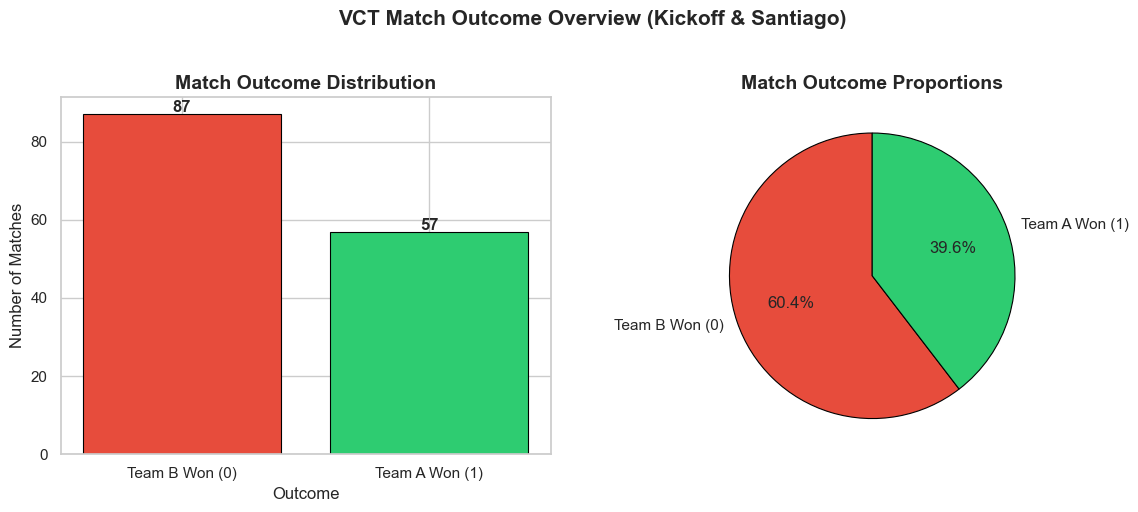

Plot 1 saved!


In [107]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Count of wins 
outcome_counts = match_df['target'].value_counts()
outcome_labels = ['Team B Won (0)', 'Team A Won (1)']
colors = ['#E74C3C', '#2ECC71']

axes[0].bar(outcome_labels, outcome_counts.values, color=colors, 
            edgecolor='black', linewidth=0.8)
axes[0].set_title('Match Outcome Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Matches')
axes[0].set_xlabel('Outcome')
for i, v in enumerate(outcome_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Plot 2: Percentage pie chart 
axes[1].pie(outcome_counts.values, labels=outcome_labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1].set_title('Match Outcome Proportions', fontsize=14, fontweight='bold')

plt.suptitle('VCT Match Outcome Overview (Kickoff & Santiago)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_plot1_outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved!")

In [108]:
# Reshape data for easier plotting 
# Create a "winning team" and "losing team" stats view

win_ratings = []
lose_ratings = []
win_acs = []
lose_acs = []

for _, row in match_df.iterrows():
    if row['target'] == 1:  # Team A won
        win_ratings.append(row['team_a_Rating'])
        lose_ratings.append(row['team_b_Rating'])
        win_acs.append(row['team_a_Average Combat Score'])
        lose_acs.append(row['team_b_Average Combat Score'])
    else:  # Team B won
        win_ratings.append(row['team_b_Rating'])
        lose_ratings.append(row['team_a_Rating'])
        win_acs.append(row['team_b_Average Combat Score'])
        lose_acs.append(row['team_a_Average Combat Score'])

plot_df = pd.DataFrame({
    'Rating': win_ratings + lose_ratings,
    'ACS': win_acs + lose_acs,
    'Outcome': ['Winner'] * len(win_ratings) + ['Loser'] * len(lose_ratings)
})

print("Plot dataframe shape:", plot_df.shape)
print(plot_df.groupby('Outcome')[['Rating', 'ACS']].describe())

Plot dataframe shape: (288, 3)
        Rating                                                              \
         count      mean       std       min       25%       50%       75%   
Outcome                                                                      
Loser    144.0  0.910835  0.107713  0.584000  0.843929  0.921544  0.970192   
Winner   144.0  1.074256  0.106142  0.745556  1.009006  1.076479  1.132976   

                     ACS                                                 \
              max  count        mean        std         min         25%   
Outcome                                                                   
Loser    1.271111  144.0  185.097825  14.777438  143.692308  176.491667   
Winner   1.483636  144.0  205.463682  15.761926  162.727273  195.741728   

                                             
                50%         75%         max  
Outcome                                      
Loser    186.686508  193.687500  223.600000  
Winner   206.63888

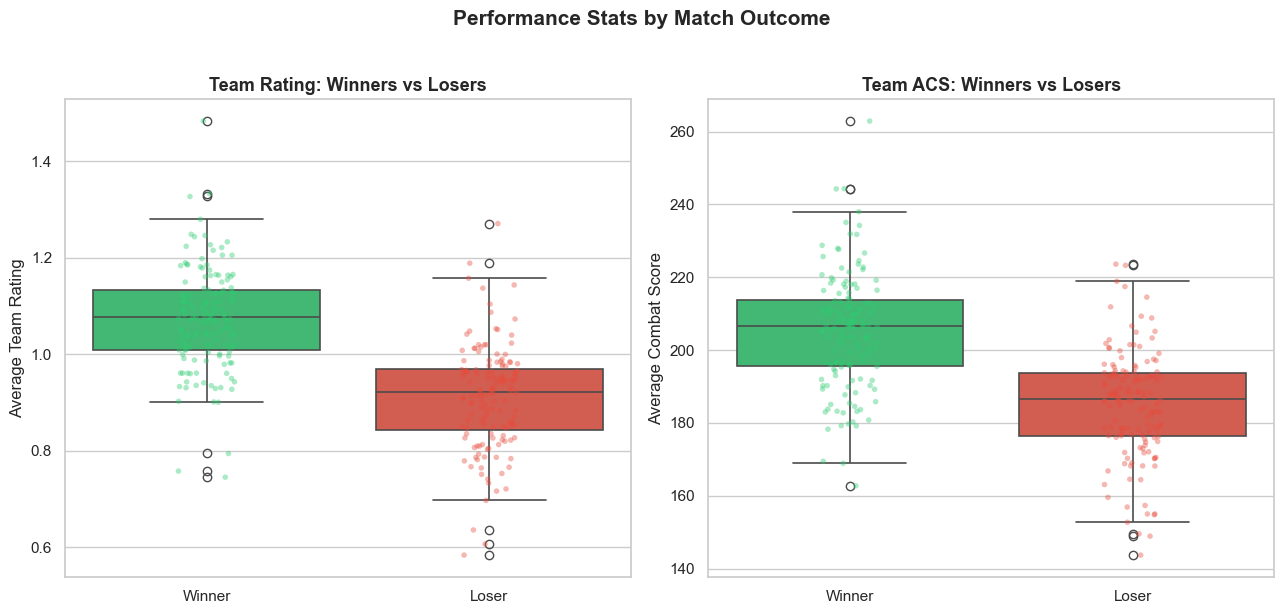

Plot 2 saved!


In [109]:
# Plot 
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
palette = {'Winner': '#2ECC71', 'Loser': '#E74C3C'}

# Boxplot: Rating
sns.boxplot(data=plot_df, x='Outcome', y='Rating',
            palette=palette, ax=axes[0],
            order=['Winner', 'Loser'],
            linewidth=1.2)
sns.stripplot(data=plot_df, x='Outcome', y='Rating',
              palette=palette, ax=axes[0],
              order=['Winner', 'Loser'],
              alpha=0.4, jitter=True, size=4)
axes[0].set_title('Team Rating: Winners vs Losers',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Team Rating')
axes[0].set_xlabel('')

# Boxplot: ACS
sns.boxplot(data=plot_df, x='Outcome', y='ACS',
            palette=palette, ax=axes[1],
            order=['Winner', 'Loser'],
            linewidth=1.2)
sns.stripplot(data=plot_df, x='Outcome', y='ACS',
              palette=palette, ax=axes[1],
              order=['Winner', 'Loser'],
              alpha=0.4, jitter=True, size=4)
axes[1].set_title('Team ACS: Winners vs Losers',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Combat Score')
axes[1].set_xlabel('')

plt.suptitle('Performance Stats by Match Outcome',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_plot2_rating_acs_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved!")

In [110]:
# Build correlation matrix using team differentials 
# Instead of correlating team_a and team_b separately,
# we compute the DIFFERENCE (Team A - Team B) for each stat.
# This is more meaningful: a positive diff = Team A was better in that stat.

diff_df = pd.DataFrame()

for col in numeric_features:
    diff_df[f'diff_{col}'] = match_df[f'team_a_{col}'] - match_df[f'team_b_{col}']

diff_df['target'] = match_df['target']

# Rename columns for cleaner plot labels
rename_map = {
    'diff_Rating': 'Rating Diff',
    'diff_Average Combat Score': 'ACS Diff',
    'diff_Kills': 'Kills Diff',
    'diff_Deaths': 'Deaths Diff',
    'diff_Assists': 'Assists Diff',
    'diff_Kill, Assist, Trade, Survive %': 'KAST Diff',
    'diff_Average Damage Per Round': 'ADR Diff',
    'diff_Headshot %': 'HS% Diff',
    'diff_First Kills': 'FK Diff',
    'diff_First Deaths': 'FD Diff',
    'diff_Kills Per Round': 'KPR Diff',
    'diff_Assists Per Round': 'APR Diff',
    'diff_First Kills Per Round': 'FKPR Diff',
    'diff_First Deaths Per Round': 'FDPR Diff',
    'diff_Clutch Success %': 'Clutch% Diff',
    'target': 'Match Result'
}
diff_df = diff_df.rename(columns=rename_map)

print("Differential feature matrix shape:", diff_df.shape)
print(diff_df.head(3))

Differential feature matrix shape: (144, 16)
   Rating Diff   ACS Diff  Kills Diff  Deaths Diff  Assists Diff  KAST Diff  \
0     0.196923  13.868132    5.879121     1.824176      8.054945   4.912088   
1    -0.416573 -28.440559   -2.181818     5.139860     -1.965035 -14.762238   
2    -0.226410 -29.692308   -1.230769     6.384615      2.085470  -2.504274   

    ADR Diff  HS% Diff   FK Diff   FD Diff  KPR Diff  APR Diff  FKPR Diff  \
0   4.043956 -5.681319 -0.186813  1.439560  0.011319  0.195165  -0.031538   
1 -10.300699  2.860140  0.244755  0.216783 -0.129650 -0.112168  -0.003916   
2 -24.974359 -4.948718  1.205128 -0.008547 -0.126667  0.034017   0.033761   

   FDPR Diff  Clutch% Diff  Match Result  
0   0.021099      16.50000             1  
1   0.011958     -22.52381             0  
2  -0.011197     -19.50000             0  


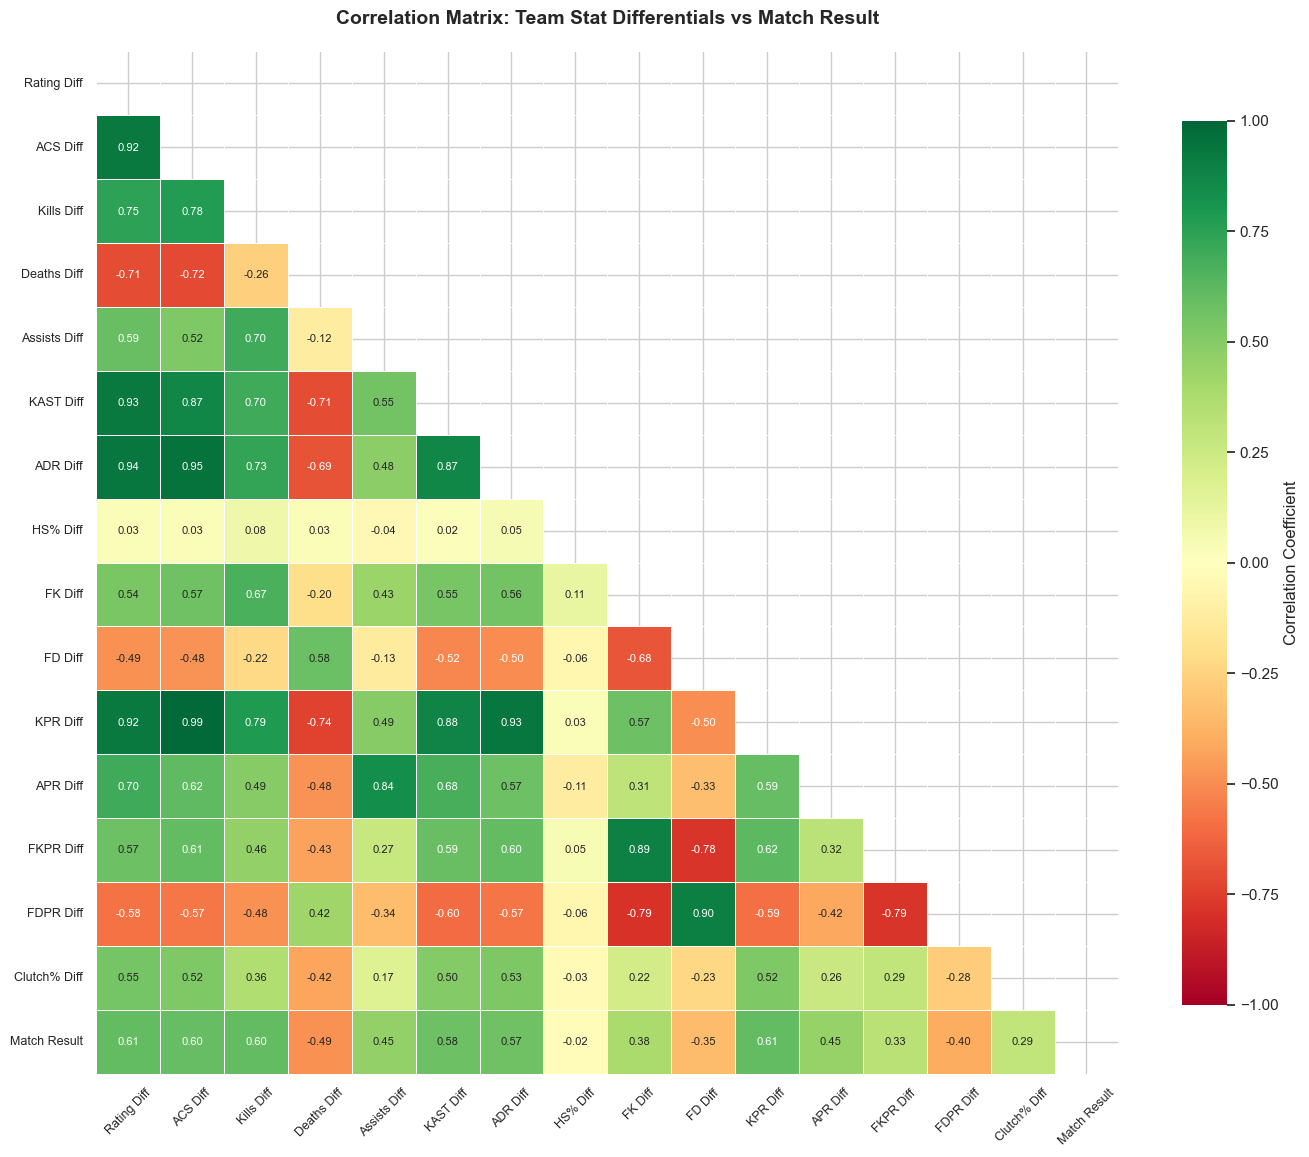

Plot 3 saved!


In [111]:
# Plot correlation heatmap 
corr_matrix = diff_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # mask upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)

ax.set_title('Correlation Matrix: Team Stat Differentials vs Match Result',
             fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('eda_plot3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved!")

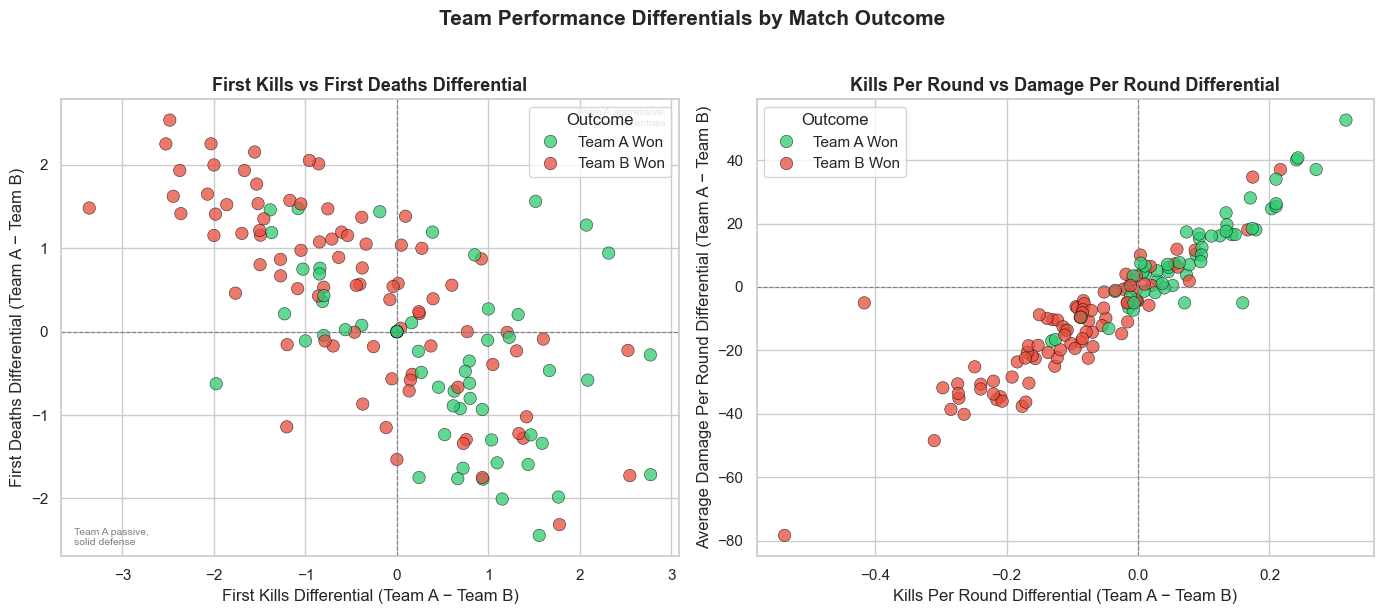

Plot 4 saved!


In [112]:
# Build scatter data 
scatter_df = pd.DataFrame({
    'FK Diff': diff_df['FK Diff'],
    'FD Diff': diff_df['FD Diff'],
    'KPR Diff': diff_df['KPR Diff'],
    'ADR Diff': diff_df['ADR Diff'],
    'Match Result': diff_df['Match Result'].map({1: 'Team A Won', 0: 'Team B Won'})
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette = {'Team A Won': '#2ECC71', 'Team B Won': '#E74C3C'}

# Plot 1: First Kills Diff vs First Deaths Diff 
sns.scatterplot(
    data=scatter_df,
    x='FK Diff', y='FD Diff',
    hue='Match Result',
    palette=palette,
    alpha=0.75, s=80,
    edgecolor='black', linewidth=0.4,
    ax=axes[0]
)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('First Kills vs First Deaths Differential',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('First Kills Differential (Team A − Team B)')
axes[0].set_ylabel('First Deaths Differential (Team A − Team B)')
axes[0].legend(title='Outcome')

# Annotate quadrants
axes[0].text(0.98, 0.98, 'Team A aggressive,\ngives up entries',
             transform=axes[0].transAxes, fontsize=7.5,
             ha='right', va='top', color='gray')
axes[0].text(0.02, 0.02, 'Team A passive,\nsolid defense',
             transform=axes[0].transAxes, fontsize=7.5,
             ha='left', va='bottom', color='gray')

#  Plot 2: KPR Diff vs ADR Diff 
sns.scatterplot(
    data=scatter_df,
    x='KPR Diff', y='ADR Diff',
    hue='Match Result',
    palette=palette,
    alpha=0.75, s=80,
    edgecolor='black', linewidth=0.4,
    ax=axes[1]
)
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Kills Per Round vs Damage Per Round Differential',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kills Per Round Differential (Team A − Team B)')
axes[1].set_ylabel('Average Damage Per Round Differential (Team A − Team B)')
axes[1].legend(title='Outcome')

plt.suptitle('Team Performance Differentials by Match Outcome',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_plot4_scatter_differentials.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved!")

In [113]:
# Compute Team A win rate by Stage 
stage_wins = match_df.groupby(['Tournament', 'Stage'])['target'].agg(
    ['sum', 'count']
).reset_index()
stage_wins.columns = ['Tournament', 'Stage', 'Team A Wins', 'Total Matches']
stage_wins['Team A Win Rate'] = (stage_wins['Team A Wins'] / 
                                  stage_wins['Total Matches'] * 100).round(1)
stage_wins['Label'] = stage_wins['Tournament'].str.replace(
    'Valorant ', '').str.replace('2026', '').str.strip() + '\n' + stage_wins['Stage']

print(stage_wins[['Tournament', 'Stage', 'Team A Wins', 
                   'Total Matches', 'Team A Win Rate']])

                       Tournament        Stage  Team A Wins  Total Matches  \
0      VCT 2026: Americas Kickoff   Main Event           10             30   
1         VCT 2026: China Kickoff   Main Event           17             30   
2          VCT 2026: EMEA Kickoff   Main Event            9             30   
3       VCT 2026: Pacific Kickoff   Main Event           10             30   
4  Valorant Masters Santiago 2026     Playoffs            7             14   
5  Valorant Masters Santiago 2026  Swiss Stage            4             10   

   Team A Win Rate  
0             33.3  
1             56.7  
2             30.0  
3             33.3  
4             50.0  
5             40.0  


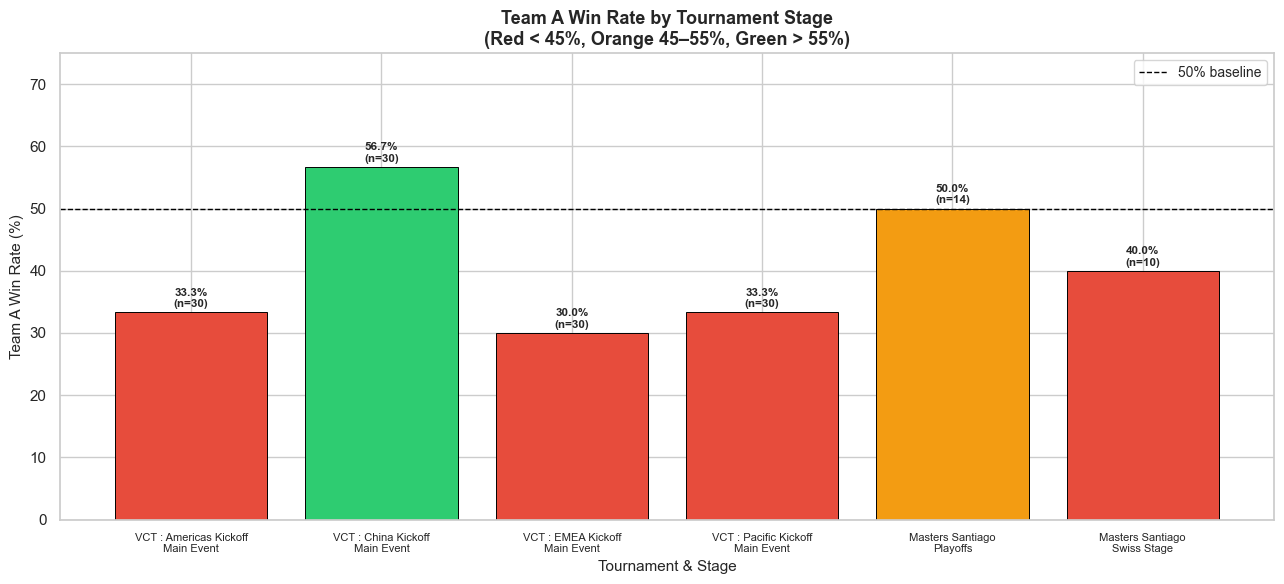

Plot 5 saved!


In [114]:
# Plot 
fig, ax = plt.subplots(figsize=(13, 6))

colors = ['#E74C3C' if r < 45 else '#F39C12' if r < 55 
          else '#2ECC71' for r in stage_wins['Team A Win Rate']]

bars = ax.bar(stage_wins['Label'], stage_wins['Team A Win Rate'],
              color=colors, edgecolor='black', linewidth=0.7)

# Add value labels on bars
for bar, val, total in zip(bars, stage_wins['Team A Win Rate'], 
                            stage_wins['Total Matches']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val}%\n(n={total})',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.axhline(50, color='black', linestyle='--', linewidth=1, label='50% baseline')
ax.set_ylim(0, 75)
ax.set_ylabel('Team A Win Rate (%)', fontsize=11)
ax.set_xlabel('Tournament & Stage', fontsize=11)
ax.set_title('Team A Win Rate by Tournament Stage\n(Red < 45%, Orange 45–55%, Green > 55%)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.savefig('eda_plot5_winrate_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 saved!")

In [115]:
# Define feature matrix and target 
# Use the differential features we already built — they're more 
# informative than raw team_a / team_b columns separately

feature_cols = [col for col in diff_df.columns if col != 'Match Result']
X = diff_df[feature_cols]
y = diff_df['Match Result']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(feature_cols)

Feature matrix shape: (144, 15)
Target shape: (144,)

Feature columns:
['Rating Diff', 'ACS Diff', 'Kills Diff', 'Deaths Diff', 'Assists Diff', 'KAST Diff', 'ADR Diff', 'HS% Diff', 'FK Diff', 'FD Diff', 'KPR Diff', 'APR Diff', 'FKPR Diff', 'FDPR Diff', 'Clutch% Diff']


In [116]:
# Stratified Train/Test Split (70/30) 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=131,       
    stratify=y              # stratify on outcome 
)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())
print(f"Training Team A win rate: {y_train.mean():.2%}")

print("\nTesting target distribution:")
print(y_test.value_counts())
print(f"Testing Team A win rate:  {y_test.mean():.2%}")

Training set size: (100, 15)
Testing set size:  (44, 15)

Training target distribution:
Match Result
0    60
1    40
Name: count, dtype: int64
Training Team A win rate: 40.00%

Testing target distribution:
Match Result
0    27
1    17
Name: count, dtype: int64
Testing Team A win rate:  38.64%


In [117]:
# Verify stratification worked
train_pct = y_train.mean()
test_pct  = y_test.mean()
full_pct  = y.mean()

print("\nStratification Check:")
print(f"  Full dataset Team A win rate:  {full_pct:.2%}")
print(f"  Training set Team A win rate:  {train_pct:.2%}")
print(f"  Testing set  Team A win rate:  {test_pct:.2%}")
print(f"\n  ✅ Stratification successful!" 
      if abs(train_pct - test_pct) < 0.05 
      else "  ⚠️ Check stratification")


Stratification Check:
  Full dataset Team A win rate:  39.58%
  Training set Team A win rate:  40.00%
  Testing set  Team A win rate:  38.64%

  ✅ Stratification successful!


In [118]:
# Define Stratified K-Fold Cross Validation
# k=5 is standard for datasets of this size (100 training samples)
# Stratified ensures each fold maintains the ~40/60 class ratio

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=131)

print("Cross-Validation Configuration:")
print(f"  Method:      Stratified K-Fold")
print(f"  K (folds):   5")
print(f"  Shuffle:     True")
print(f"  Random seed: 131")

# Preview what each fold looks like 
print("\nFold-by-fold breakdown:")
print(f"{'Fold':<6} {'Train Size':<12} {'Val Size':<10} {'Train Win%':<12} {'Val Win%'}")
print("-" * 55)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    fold_train_y = y_train.iloc[train_idx]
    fold_val_y   = y_train.iloc[val_idx]
    print(f"{fold:<6} {len(train_idx):<12} {len(val_idx):<10} "
          f"{fold_train_y.mean():.2%}      {fold_val_y.mean():.2%}")

Cross-Validation Configuration:
  Method:      Stratified K-Fold
  K (folds):   5
  Shuffle:     True
  Random seed: 131

Fold-by-fold breakdown:
Fold   Train Size   Val Size   Train Win%   Val Win%
-------------------------------------------------------
1      80           20         40.00%      40.00%
2      80           20         40.00%      40.00%
3      80           20         40.00%      40.00%
4      80           20         40.00%      40.00%
5      80           20         40.00%      40.00%


In [119]:
# Quick baseline: what accuracy would always predicting Team B give?
baseline_acc = (y_train == 0).sum() / len(y_train)
print(f"\nBaseline accuracy (always predict Team B wins): {baseline_acc:.2%}")
print("Our models must beat this to be useful!")
print(f"\nTraining set: {X_train.shape[0]} matches")
print(f"Each fold trains on ~{int(X_train.shape[0]*0.8)} and validates on ~{int(X_train.shape[0]*0.2)} matches")


Baseline accuracy (always predict Team B wins): 60.00%
Our models must beat this to be useful!

Training set: 100 matches
Each fold trains on ~80 and validates on ~20 matches


In [120]:
# All features are already numeric differentials
# No categorical encoding needed since we dropped Team A/B name columns
# We just need scaling for distance-based models (SVM, Logistic Regression)

# Confirm all features are numeric
print("Feature dtypes:")
print(X_train.dtypes)
print(f"\nAny nulls in X_train: {X_train.isnull().sum().sum()}")
print(f"Any nulls in X_test:  {X_test.isnull().sum().sum()}")

Feature dtypes:
Rating Diff     float64
ACS Diff        float64
Kills Diff      float64
Deaths Diff     float64
Assists Diff    float64
KAST Diff       float64
ADR Diff        float64
HS% Diff        float64
FK Diff         float64
FD Diff         float64
KPR Diff        float64
APR Diff        float64
FKPR Diff       float64
FDPR Diff       float64
Clutch% Diff    float64
dtype: object

Any nulls in X_train: 0
Any nulls in X_test:  0


In [121]:
# Build preprocessing pipeline 
# StandardScaler: centers each feature to mean=0, std=1
# Critical for Logistic Regression and SVM
# Tree-based models (RF, GBT) don't require scaling but it doesn't hurt

preprocessor = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Fit on training data only — NEVER fit on test data 
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled  = preprocessor.transform(X_test)   # transform only!

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, 
                                columns=feature_cols)
X_test_scaled  = pd.DataFrame(X_test_scaled,  
                                columns=feature_cols)

print("Scaling complete!")
print(f"\nX_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

print("\nMean of each feature after scaling (should be ~0):")
print(X_train_scaled.mean().round(3))
print("\nStd of each feature after scaling (should be ~1):")
print(X_train_scaled.std().round(3))

Scaling complete!

X_train_scaled shape: (100, 15)
X_test_scaled shape:  (44, 15)

Mean of each feature after scaling (should be ~0):
Rating Diff     0.0
ACS Diff       -0.0
Kills Diff     -0.0
Deaths Diff    -0.0
Assists Diff   -0.0
KAST Diff       0.0
ADR Diff        0.0
HS% Diff       -0.0
FK Diff         0.0
FD Diff         0.0
KPR Diff       -0.0
APR Diff        0.0
FKPR Diff      -0.0
FDPR Diff       0.0
Clutch% Diff   -0.0
dtype: float64

Std of each feature after scaling (should be ~1):
Rating Diff     1.005
ACS Diff        1.005
Kills Diff      1.005
Deaths Diff     1.005
Assists Diff    1.005
KAST Diff       1.005
ADR Diff        1.005
HS% Diff        1.005
FK Diff         1.005
FD Diff         1.005
KPR Diff        1.005
APR Diff        1.005
FKPR Diff       1.005
FDPR Diff       1.005
Clutch% Diff    1.005
dtype: float64


In [122]:
# Logistic Regression (Elastic Net) 
# Elastic net combines L1 (Lasso) + L2 (Ridge) regularization
# Great for our data since we have multicollinear features (ACS/Rating/KPR)

lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],        # regularization strength
    'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]     # 0=Ridge, 1=Lasso, mid=ElasticNet
}

lr_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=10000,
    random_state=131
)

lr_grid = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

lr_grid.fit(X_train_scaled, y_train)

print("=" * 50)
print("LOGISTIC REGRESSION (Elastic Net) RESULTS")
print("=" * 50)
print(f"Best Parameters:    {lr_grid.best_params_}")
print(f"Best CV Accuracy:   {lr_grid.best_score_:.4f} ({lr_grid.best_score_*100:.2f}%)")
print(f"Baseline Accuracy:  {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Improvement:        +{(lr_grid.best_score_ - baseline_acc)*100:.2f}%")

LOGISTIC REGRESSION (Elastic Net) RESULTS
Best Parameters:    {'C': 0.1, 'l1_ratio': 0.5}
Best CV Accuracy:   0.8400 (84.00%)
Baseline Accuracy:  0.6000 (60.00%)
Improvement:        +24.00%


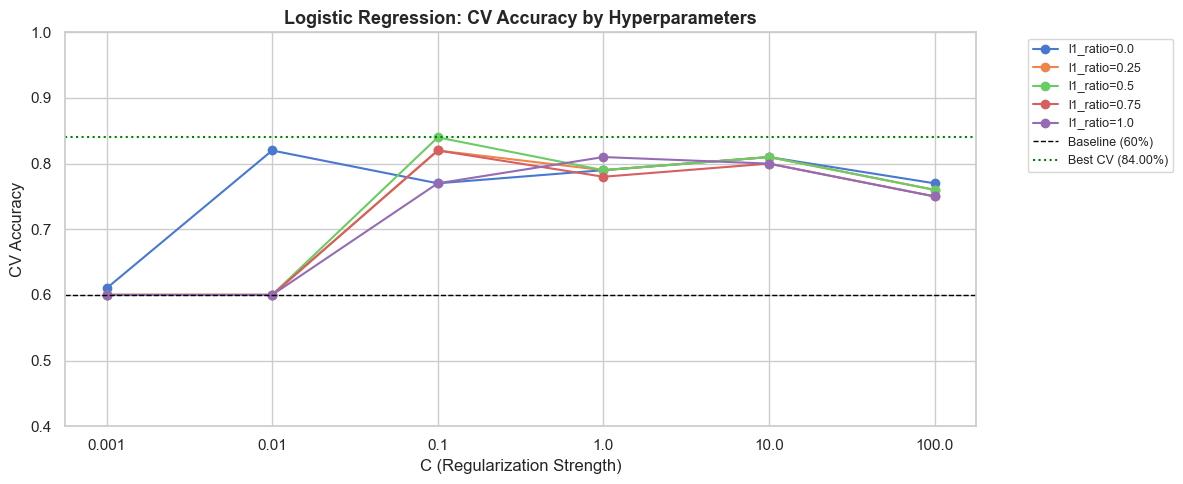

Logistic Regression tuning plot saved!


In [123]:
# Visualize tuning results 
results_lr = pd.DataFrame(lr_grid.cv_results_)

fig, ax = plt.subplots(figsize=(12, 5))

for l1 in lr_param_grid['l1_ratio']:
    subset = results_lr[results_lr['param_l1_ratio'] == l1]
    subset = subset.sort_values('param_C')
    ax.plot(subset['param_C'].astype(str),
            subset['mean_test_score'],
            marker='o', label=f'l1_ratio={l1}', linewidth=1.5)

ax.axhline(baseline_acc, color='black', linestyle='--',
           linewidth=1, label=f'Baseline ({baseline_acc:.0%})')
ax.axhline(lr_grid.best_score_, color='green', linestyle=':',
           linewidth=1.5, label=f'Best CV ({lr_grid.best_score_:.2%})')

ax.set_title('Logistic Regression: CV Accuracy by Hyperparameters',
             fontsize=13, fontweight='bold')
ax.set_xlabel('C (Regularization Strength)')
ax.set_ylabel('CV Accuracy')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.savefig('tuning_plot1_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Logistic Regression tuning plot saved!")

In [124]:
# Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],        # number of trees in the forest
    'max_depth': [3, 5, 10, None],          # how deep each tree can grow
    'max_features': ['sqrt', 'log2', None], # features considered at each split
    'min_samples_split': [2, 5, 10]         # min samples needed to split a node
}

rf_model = RandomForestClassifier(
    random_state=131,
    class_weight='balanced'   # handles our 40/60 class imbalance
)

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

rf_grid.fit(X_train_scaled, y_train)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Best Parameters:    {rf_grid.best_params_}")
print(f"Best CV Accuracy:   {rf_grid.best_score_:.4f} ({rf_grid.best_score_*100:.2f}%)")
print(f"Baseline Accuracy:  {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Improvement:        +{(rf_grid.best_score_ - baseline_acc)*100:.2f}%")

RANDOM FOREST RESULTS
Best Parameters:    {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy:   0.8200 (82.00%)
Baseline Accuracy:  0.6000 (60.00%)
Improvement:        +22.00%


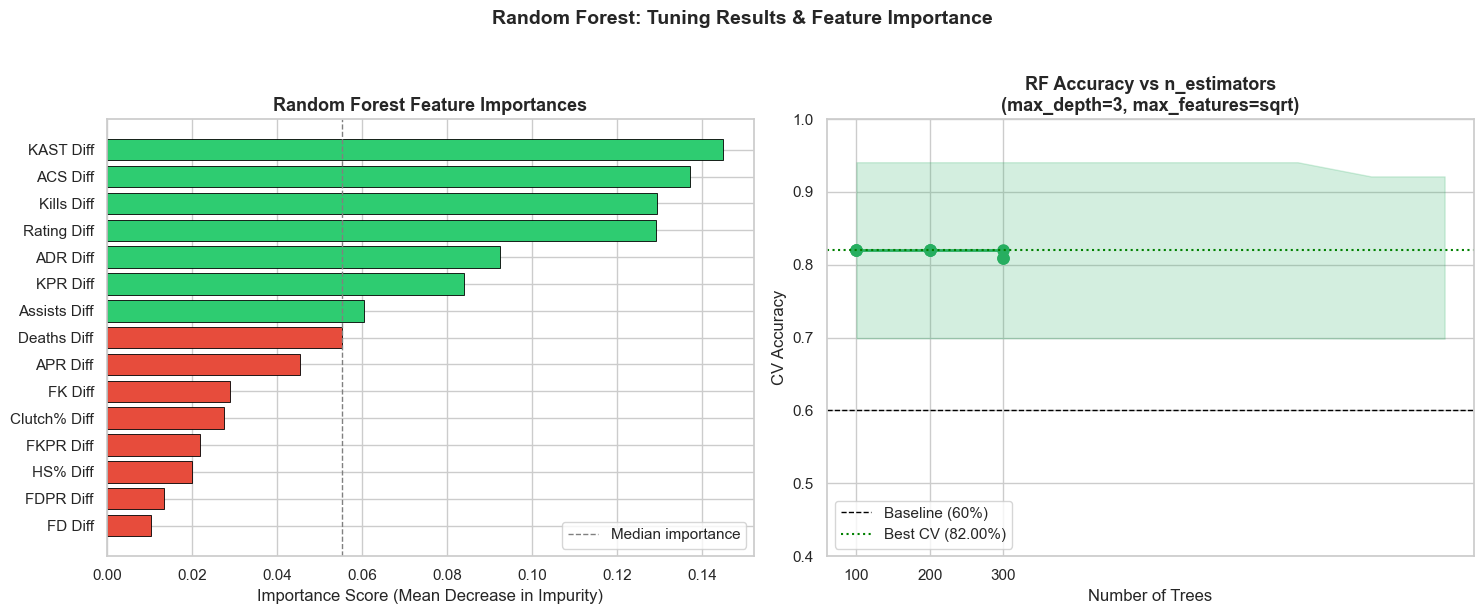

Random Forest tuning plot saved!


In [125]:
# Feature Importance Plot 
best_rf = rf_grid.best_estimator_

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Feature importance bar chart
colors = ['#2ECC71' if imp > importance_df['Importance'].median() 
          else '#E74C3C' for imp in importance_df['Importance']]

axes[0].barh(importance_df['Feature'], importance_df['Importance'],
             color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_title('Random Forest Feature Importances',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score (Mean Decrease in Impurity)')
axes[0].axvline(importance_df['Importance'].median(), 
                color='gray', linestyle='--', linewidth=1,
                label='Median importance')
axes[0].legend()

# Right: CV accuracy across n_estimators for best max_depth
results_rf = pd.DataFrame(rf_grid.cv_results_)
best_depth = rf_grid.best_params_['max_depth']
best_features = rf_grid.best_params_['max_features']

subset = results_rf[
    (results_rf['param_max_depth'] == best_depth) &
    (results_rf['param_max_features'] == best_features)
].sort_values('param_n_estimators')

axes[1].plot(subset['param_n_estimators'].astype(str),
             subset['mean_test_score'],
             marker='o', color='#27AE60', linewidth=2, markersize=8)
axes[1].fill_between(
    range(len(subset)),
    subset['mean_test_score'] - subset['std_test_score'],
    subset['mean_test_score'] + subset['std_test_score'],
    alpha=0.2, color='#27AE60'
)
axes[1].axhline(baseline_acc, color='black', linestyle='--',
                linewidth=1, label=f'Baseline ({baseline_acc:.0%})')
axes[1].axhline(rf_grid.best_score_, color='green', linestyle=':',
                linewidth=1.5, label=f'Best CV ({rf_grid.best_score_:.2%})')
axes[1].set_title(f'RF Accuracy vs n_estimators\n(max_depth={best_depth}, max_features={best_features})',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('CV Accuracy')
axes[1].legend()
axes[1].set_ylim(0.4, 1.0)

plt.suptitle('Random Forest: Tuning Results & Feature Importance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tuning_plot2_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print("Random Forest tuning plot saved!")

In [126]:
#Gradient Boosting Classifier 
gbt_param_grid = {
    'n_estimators': [100, 200, 300],         # number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.2], # how much each tree contributes
    'max_depth': [2, 3, 4],                   # depth of each weak learner
    'subsample': [0.7, 0.8, 1.0]             # fraction of samples per tree
}

gbt_model = GradientBoostingClassifier(random_state=131)

gbt_grid = RandomizedSearchCV(    # RandomizedSearch since grid is large (108 combos)
    estimator=gbt_model,
    param_distributions=gbt_param_grid,
    n_iter=40,                    # try 40 random combinations
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    random_state=131,
    verbose=0
)

gbt_grid.fit(X_train_scaled, y_train)

print("=" * 50)
print("GRADIENT BOOSTED TREE RESULTS")
print("=" * 50)
print(f"Best Parameters:    {gbt_grid.best_params_}")
print(f"Best CV Accuracy:   {gbt_grid.best_score_:.4f} ({gbt_grid.best_score_*100:.2f}%)")
print(f"Baseline Accuracy:  {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Improvement:        +{(gbt_grid.best_score_ - baseline_acc)*100:.2f}%")

GRADIENT BOOSTED TREE RESULTS
Best Parameters:    {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}
Best CV Accuracy:   0.8300 (83.00%)
Baseline Accuracy:  0.6000 (60.00%)
Improvement:        +23.00%


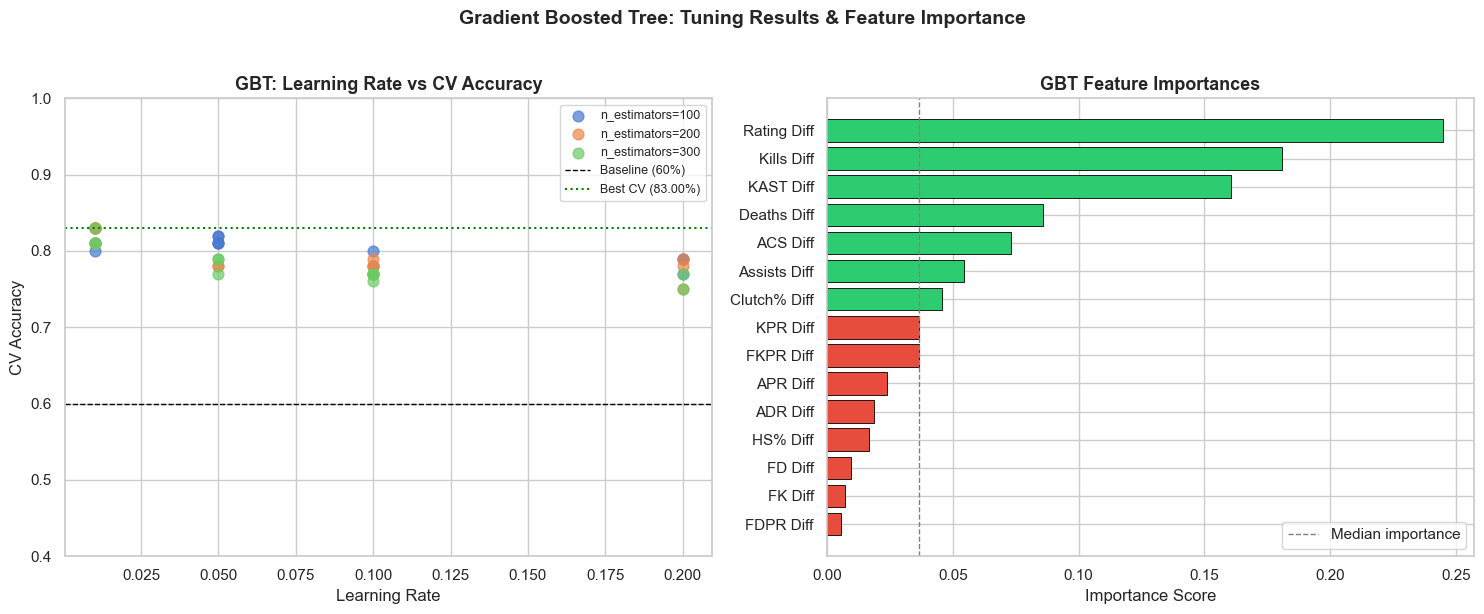

Gradient Boosting tuning plot saved!


In [127]:
# Visualize tuning results 
results_gbt = pd.DataFrame(gbt_grid.cv_results_)
best_depth_gbt = gbt_grid.best_params_['max_depth']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: learning rate vs accuracy for each n_estimators
for n_est in [100, 200, 300]:
    subset = results_gbt[
        results_gbt['param_n_estimators'] == n_est
    ].sort_values('param_learning_rate')
    if len(subset) > 0:
        axes[0].scatter(subset['param_learning_rate'].astype(float),
                        subset['mean_test_score'],
                        label=f'n_estimators={n_est}',
                        alpha=0.7, s=60)

axes[0].axhline(baseline_acc, color='black', linestyle='--',
                linewidth=1, label=f'Baseline ({baseline_acc:.0%})')
axes[0].axhline(gbt_grid.best_score_, color='green', linestyle=':',
                linewidth=1.5, label=f'Best CV ({gbt_grid.best_score_:.2%})')
axes[0].set_title('GBT: Learning Rate vs CV Accuracy',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('CV Accuracy')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.4, 1.0)

# Right: feature importance from best GBT model
best_gbt = gbt_grid.best_estimator_
gbt_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_gbt.feature_importances_
}).sort_values('Importance', ascending=True)

colors_gbt = ['#2ECC71' if imp > gbt_importance_df['Importance'].median()
              else '#E74C3C' for imp in gbt_importance_df['Importance']]

axes[1].barh(gbt_importance_df['Feature'], gbt_importance_df['Importance'],
             color=colors_gbt, edgecolor='black', linewidth=0.6)
axes[1].set_title('GBT Feature Importances',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].axvline(gbt_importance_df['Importance'].median(),
                color='gray', linestyle='--', linewidth=1,
                label='Median importance')
axes[1].legend()

plt.suptitle('Gradient Boosted Tree: Tuning Results & Feature Importance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tuning_plot3_gradient_boosting.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gradient Boosting tuning plot saved!")

In [128]:
# Support Vector Machine 
svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],                    # regularization
    'kernel': ['linear', 'rbf', 'poly'],              # decision boundary shape
    'gamma': ['scale', 'auto', 0.01, 0.1]            # kernel coefficient
}

svm_model = SVC(
    random_state=131,
    probability=True,       # enables predict_proba for win probability later
    class_weight='balanced'
)

svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

svm_grid.fit(X_train_scaled, y_train)

print("=" * 50)
print("SUPPORT VECTOR MACHINE RESULTS")
print("=" * 50)
print(f"Best Parameters:    {svm_grid.best_params_}")
print(f"Best CV Accuracy:   {svm_grid.best_score_:.4f} ({svm_grid.best_score_*100:.2f}%)")
print(f"Baseline Accuracy:  {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Improvement:        +{(svm_grid.best_score_ - baseline_acc)*100:.2f}%")

SUPPORT VECTOR MACHINE RESULTS
Best Parameters:    {'C': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
Best CV Accuracy:   0.8400 (84.00%)
Baseline Accuracy:  0.6000 (60.00%)
Improvement:        +24.00%


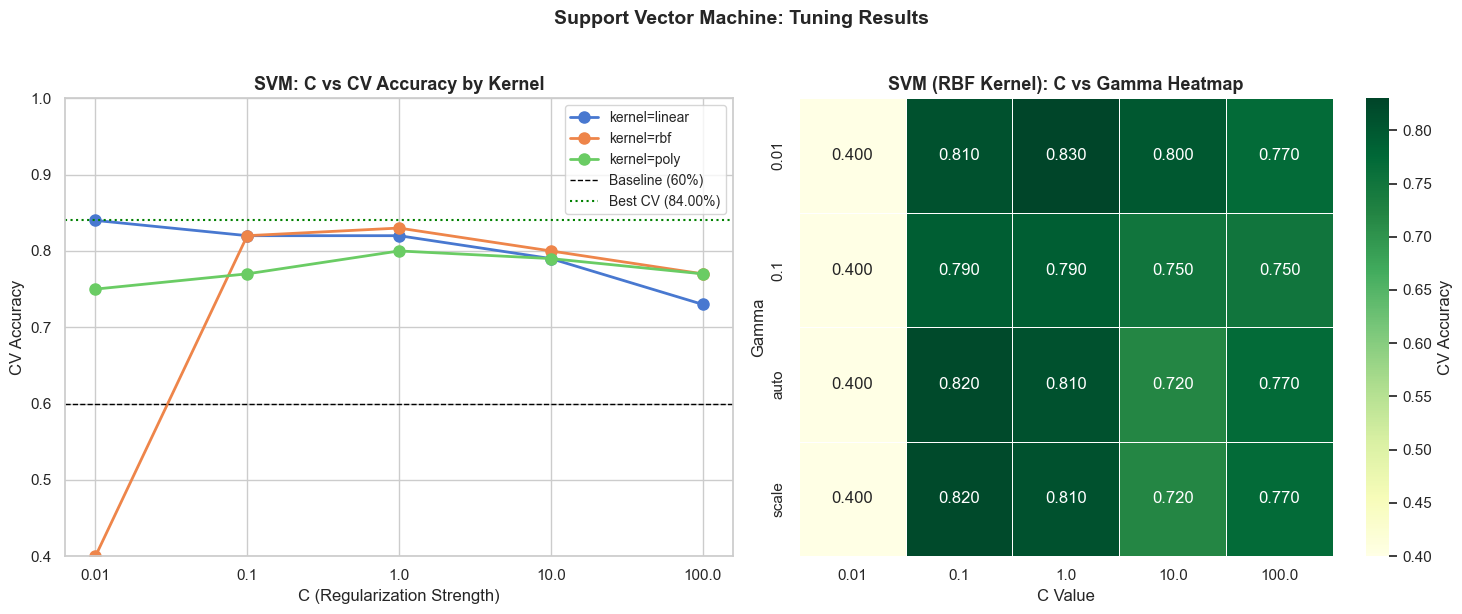

SVM tuning plot saved!


In [129]:
# Visualize tuning results 
results_svm = pd.DataFrame(svm_grid.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: C vs accuracy for each kernel
for kernel in ['linear', 'rbf', 'poly']:
    subset = results_svm[
        results_svm['param_kernel'] == kernel
    ].groupby('param_C')['mean_test_score'].max().reset_index()
    subset = subset.sort_values('param_C')
    axes[0].plot(subset['param_C'].astype(str),
                 subset['mean_test_score'],
                 marker='o', label=f'kernel={kernel}',
                 linewidth=2, markersize=8)

axes[0].axhline(baseline_acc, color='black', linestyle='--',
                linewidth=1, label=f'Baseline ({baseline_acc:.0%})')
axes[0].axhline(svm_grid.best_score_, color='green', linestyle=':',
                linewidth=1.5, label=f'Best CV ({svm_grid.best_score_:.2%})')
axes[0].set_title('SVM: C vs CV Accuracy by Kernel',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('C (Regularization Strength)')
axes[0].set_ylabel('CV Accuracy')
axes[0].legend(fontsize=10)
axes[0].set_ylim(0.4, 1.0)

# Right: Heatmap of C vs gamma for RBF kernel only
rbf_results = results_svm[results_svm['param_kernel'] == 'rbf'].copy()
rbf_results['param_C'] = rbf_results['param_C'].astype(float)
rbf_results['param_gamma'] = rbf_results['param_gamma'].astype(str)

try:
    rbf_pivot = rbf_results.pivot_table(
        index='param_gamma',
        columns='param_C',
        values='mean_test_score',
        aggfunc='max'
    )
    sns.heatmap(rbf_pivot, annot=True, fmt='.3f',
                cmap='YlGn', ax=axes[1],
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'CV Accuracy'})
    axes[1].set_title('SVM (RBF Kernel): C vs Gamma Heatmap',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('C Value')
    axes[1].set_ylabel('Gamma')
except:
    axes[1].text(0.5, 0.5, 'Heatmap not available',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.suptitle('Support Vector Machine: Tuning Results',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tuning_plot4_svm.png', dpi=150, bbox_inches='tight')
plt.show()
print("SVM tuning plot saved!")

In [130]:
# Full model comparison so far
print("\n" + "=" * 55)
print("📊 MODEL LEADERBOARD (CV Accuracy)")
print("=" * 55)
models = {
    'Logistic Regression': lr_grid.best_score_,
    'Gradient Boosting':   gbt_grid.best_score_,
    'Random Forest':       rf_grid.best_score_,
    'SVM':                 svm_grid.best_score_,
    'Baseline':            baseline_acc
}
for name, score in sorted(models.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(score * 40)
    print(f"  {name:<25} {score:.2%}  {bar}")
print("=" * 55)


📊 MODEL LEADERBOARD (CV Accuracy)
  Logistic Regression       84.00%  █████████████████████████████████
  SVM                       84.00%  █████████████████████████████████
  Gradient Boosting         83.00%  █████████████████████████████████
  Random Forest             82.00%  ████████████████████████████████
  Baseline                  60.00%  ████████████████████████


In [131]:
#  Evaluate top 2 models on test set 
best_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'SVM':                 svm_grid.best_estimator_
}

test_results = {}

for name, model in best_models.items():
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    acc     = accuracy_score(y_test, y_pred)
    auc     = roc_auc_score(y_test, y_proba)
    test_results[name] = {
        'accuracy': acc, 'auc': auc,
        'y_pred': y_pred, 'y_proba': y_proba
    }
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Test Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
    print(f"  ROC-AUC Score:  {auc:.4f}")
    print(f"  Baseline:       {baseline_acc:.2%}")
    print(f"  Improvement:    +{(acc - baseline_acc)*100:.2f}%")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Team B Won', 'Team A Won']))


  Logistic Regression
  Test Accuracy:  0.8409 (84.09%)
  ROC-AUC Score:  0.9129
  Baseline:       60.00%
  Improvement:    +24.09%

Classification Report:
              precision    recall  f1-score   support

  Team B Won       0.86      0.89      0.87        27
  Team A Won       0.81      0.76      0.79        17

    accuracy                           0.84        44
   macro avg       0.83      0.83      0.83        44
weighted avg       0.84      0.84      0.84        44


  SVM
  Test Accuracy:  0.8409 (84.09%)
  ROC-AUC Score:  0.9041
  Baseline:       60.00%
  Improvement:    +24.09%

Classification Report:
              precision    recall  f1-score   support

  Team B Won       0.88      0.85      0.87        27
  Team A Won       0.78      0.82      0.80        17

    accuracy                           0.84        44
   macro avg       0.83      0.84      0.83        44
weighted avg       0.84      0.84      0.84        44



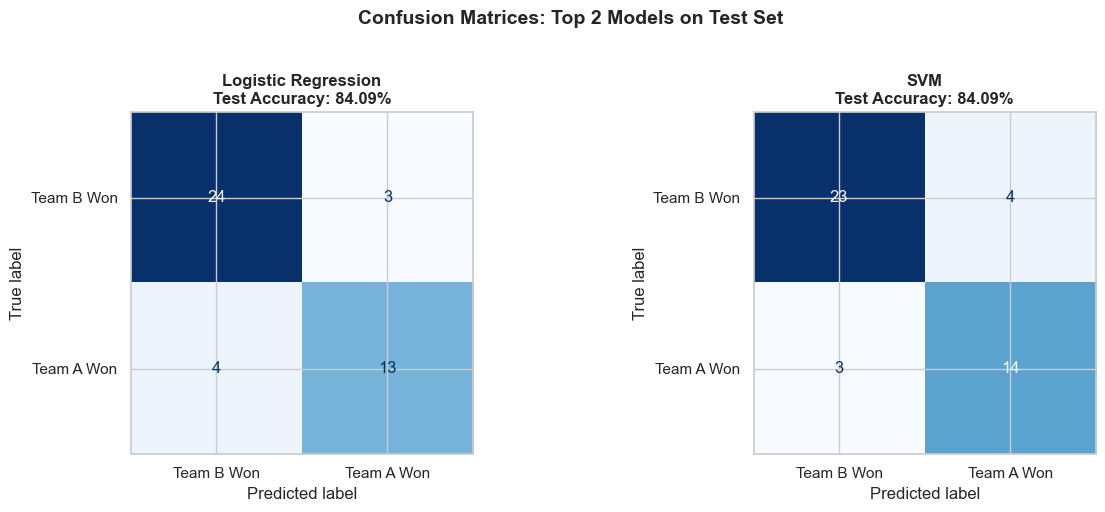

In [132]:
#  Confusion Matrices 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, results) in zip(axes, test_results.items()):
    cm = confusion_matrix(y_test, results['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Team B Won', 'Team A Won'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nTest Accuracy: {results["accuracy"]:.2%}',
                 fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices: Top 2 Models on Test Set',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eval_plot1_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

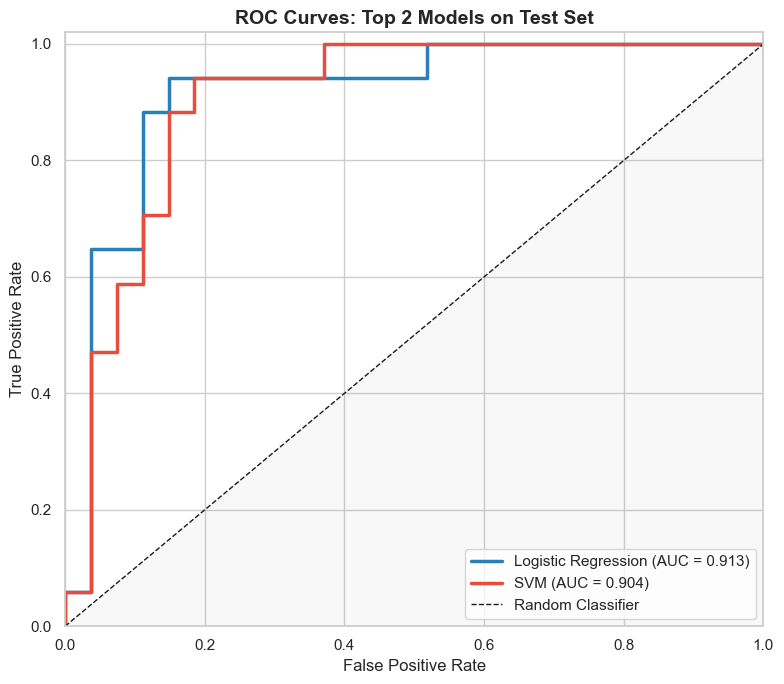

All evaluation plots saved!


In [133]:
# ROC Curves 
fig, ax = plt.subplots(figsize=(8, 7))

colors = ['#2980B9', '#E74C3C']
for (name, results), color in zip(test_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, results['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name} (AUC = {results['auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves: Top 2 Models on Test Set',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('eval_plot2_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("All evaluation plots saved!")

In [134]:
#  Final summary table 
print("\n" + "="*60)
print("🏆 FINAL TEST SET RESULTS")
print("="*60)
print(f"  {'Model':<25} {'CV Acc':>8} {'Test Acc':>10} {'ROC-AUC':>10}")
print(f"  {'-'*25} {'-'*8} {'-'*10} {'-'*10}")
cv_scores = {'Logistic Regression': lr_grid.best_score_,
             'SVM': svm_grid.best_score_}
for name, results in test_results.items():
    print(f"  {name:<25} {cv_scores[name]:>8.2%} "
          f"{results['accuracy']:>10.2%} {results['auc']:>10.3f}")
print(f"\n  {'Baseline':<25} {'60.00%':>8} {'60.00%':>10} {'0.500':>10}")
print("="*60)


🏆 FINAL TEST SET RESULTS
  Model                       CV Acc   Test Acc    ROC-AUC
  ------------------------- -------- ---------- ----------
  Logistic Regression         84.00%     84.09%      0.913
  SVM                         84.00%     84.09%      0.904

  Baseline                    60.00%     60.00%      0.500


In [135]:
# Team Stats Lookup + Name Aliases + Prediction Function 
team_stats_lookup = {}

for _, row in match_df.iterrows():
    team_a = row['Team A']
    team_b = row['Team B']

    if team_a not in team_stats_lookup:
        team_stats_lookup[team_a] = []
    team_a_stats = {col: row[f'team_a_{col}'] for col in numeric_features}
    team_stats_lookup[team_a].append(team_a_stats)

    if team_b not in team_stats_lookup:
        team_stats_lookup[team_b] = []
    team_b_stats = {col: row[f'team_b_{col}'] for col in numeric_features}
    team_stats_lookup[team_b].append(team_b_stats)

# Average each team's stats
team_avg_stats = {}
for team, stats_list in team_stats_lookup.items():
    stats_df_temp = pd.DataFrame(stats_list)
    team_avg_stats[team] = stats_df_temp.mean().to_dict()

In [136]:
# Apply name aliases 
team_aliases = {
    'Mega Minors': 'NRG',   # NRG competed under Mega Minors in dataset
    'LEVIATÁN': 'LEV'
}

for old_name, new_name in team_aliases.items():
    # Fix team_avg_stats
    if old_name in team_avg_stats:
        team_avg_stats[new_name] = team_avg_stats.pop(old_name)
        print(f"✅ Renamed '{old_name}' → '{new_name}' in team_avg_stats")
    # Fix team_stats_lookup
    if old_name in team_stats_lookup:
        team_stats_lookup[new_name] = team_stats_lookup.pop(old_name)
        print(f"✅ Renamed '{old_name}' → '{new_name}' in team_stats_lookup")
    # Fix match_df
    mask_a = match_df['Team A'] == old_name
    mask_b = match_df['Team B'] == old_name
    match_df.loc[mask_a, 'Team A'] = new_name
    match_df.loc[mask_b, 'Team B'] = new_name
    print(f"✅ Fixed match_df: {mask_a.sum() + mask_b.sum()} rows updated")

print(f"\nTotal teams available: {len(team_avg_stats)}")
print("\nAvailable teams:")
for i, team in enumerate(sorted(team_avg_stats.keys()), 1):
    print(f"  {i:>2}. {team}")

✅ Renamed 'Mega Minors' → 'NRG' in team_avg_stats
✅ Renamed 'Mega Minors' → 'NRG' in team_stats_lookup
✅ Fixed match_df: 13 rows updated
✅ Renamed 'LEVIATÁN' → 'LEV' in team_avg_stats
✅ Renamed 'LEVIATÁN' → 'LEV' in team_stats_lookup
✅ Fixed match_df: 5 rows updated

Total teams available: 48

Available teams:
   1. 100 Thieves
   2. All Gamers
   3. BBL Esports
   4. Bilibili Gaming
   5. Cloud9
   6. DRX
   7. DetonatioN FocusMe
   8. Dragon Ranger Gaming
   9. EDward Gaming
  10. ENVY
  11. Evil Geniuses
  12. FNATIC
  13. FULL SENSE
  14. FURIA
  15. FUT Esports
  16. FunPlus Phoenix
  17. G2 Esports
  18. GIANTX
  19. Gen.G
  20. Gentle Mates
  21. Global Esports
  22. JDG Esports
  23. KRÜ Esports
  24. Karmine Corp
  25. LEV
  26. LOUD
  27. MIBR
  28. NRG
  29. Natus Vincere
  30. Nongshim RedForce
  31. Nova Esports
  32. PCIFIC Esports
  33. Paper Rex
  34. Rex Regum Qeon
  35. Sentinels
  36. T1
  37. TYLOO
  38. Team Heretics
  39. Team Liquid
  40. Team Secret
  41. Team V

In [137]:
#  Prediction function 
def predict_matchup(team_a_name, team_b_name, model=lr_grid.best_estimator_,
                    verbose=True):
    if team_a_name not in team_avg_stats:
        print(f"❌ '{team_a_name}' not found. Check spelling!")
        print(f"Available: {sorted(team_avg_stats.keys())}")
        return None
    if team_b_name not in team_avg_stats:
        print(f"❌ '{team_b_name}' not found. Check spelling!")
        print(f"Available: {sorted(team_avg_stats.keys())}")
        return None

    a_stats = team_avg_stats[team_a_name]
    b_stats = team_avg_stats[team_b_name]

    diff_vector = {}
    for col, renamed in zip(numeric_features, feature_cols):
        diff_vector[renamed] = a_stats[col] - b_stats[col]

    diff_input  = pd.DataFrame([diff_vector])
    diff_scaled = preprocessor.transform(diff_input)
    diff_scaled_df = pd.DataFrame(diff_scaled, columns=feature_cols)

    prob        = model.predict_proba(diff_scaled_df)[0]
    prob_team_b = prob[0]
    prob_team_a = prob[1]
    predicted   = team_a_name if prob_team_a >= 0.5 else team_b_name
    win_prob    = prob_team_a if prob_team_a >= 0.5 else prob_team_b

    if verbose:
        print("=" * 58)
        print(f"  ⚔️  {team_a_name}  vs  {team_b_name}")
        print("=" * 58)
        print(f"\n  🏆 Predicted Winner:  {predicted}")
        print(f"  📊 Win Probability:   {win_prob:.1%}")
        print(f"\n  {team_a_name:<25} win prob: {prob_team_a:.1%}")
        print(f"  {team_b_name:<25} win prob: {prob_team_b:.1%}")
        print("\n  Key Stat Differentials (Team A − Team B):")
        print(f"  {'Stat':<20} {'Diff':>8}  {'Edge'}")
        print(f"  {'-'*45}")
        key_stats = ['Rating Diff', 'ACS Diff', 'KAST Diff',
                     'ADR Diff', 'KPR Diff', 'FK Diff', 'FD Diff']
        for stat in key_stats:
            val  = diff_vector[stat]
            edge = f"✅ {team_a_name}" if val > 0 else f"✅ {team_b_name}"
            print(f"  {stat:<20} {val:>+8.3f}  {edge}")
        print("=" * 58)

    return {
        'predicted_winner': predicted,
        'team_a_win_prob':  prob_team_a,
        'team_b_win_prob':  prob_team_b
    }

print("\n✅ Prediction function ready!")


✅ Prediction function ready!


In [138]:
# Robust prediction (averages both orderings) 
def predict_matchup_robust(team_1, team_2):
    """
    Averages predictions from both team orderings to cancel out
    the positional bias caused by Team A/B naming convention imbalance.
    """
    r1 = predict_matchup(team_1, team_2, verbose=False)
    r2 = predict_matchup(team_2, team_1, verbose=False)

    avg_prob_1 = (r1['team_a_win_prob'] + r2['team_b_win_prob']) / 2
    avg_prob_2 = 1 - avg_prob_1
    winner = team_1 if avg_prob_1 >= 0.5 else team_2

    print("=" * 50)
    print(f"  ⚔️  {team_1}  vs  {team_2}  [ROBUST]")
    print("=" * 50)
    print(f"  🏆 Predicted Winner: {winner}")
    print(f"  {team_1:<25} {avg_prob_1:.1%}")
    print(f"  {team_2:<25} {avg_prob_2:.1%}")
    print("=" * 50)

    return {'winner': winner, 'prob_1': avg_prob_1, 'prob_2': avg_prob_2}

In [139]:
predict_matchup_robust('LEV', 'NRG')

  ⚔️  LEV  vs  NRG  [ROBUST]
  🏆 Predicted Winner: NRG
  LEV                       39.2%
  NRG                       60.8%


{'winner': 'NRG',
 'prob_1': np.float64(0.39180924740361067),
 'prob_2': np.float64(0.6081907525963893)}

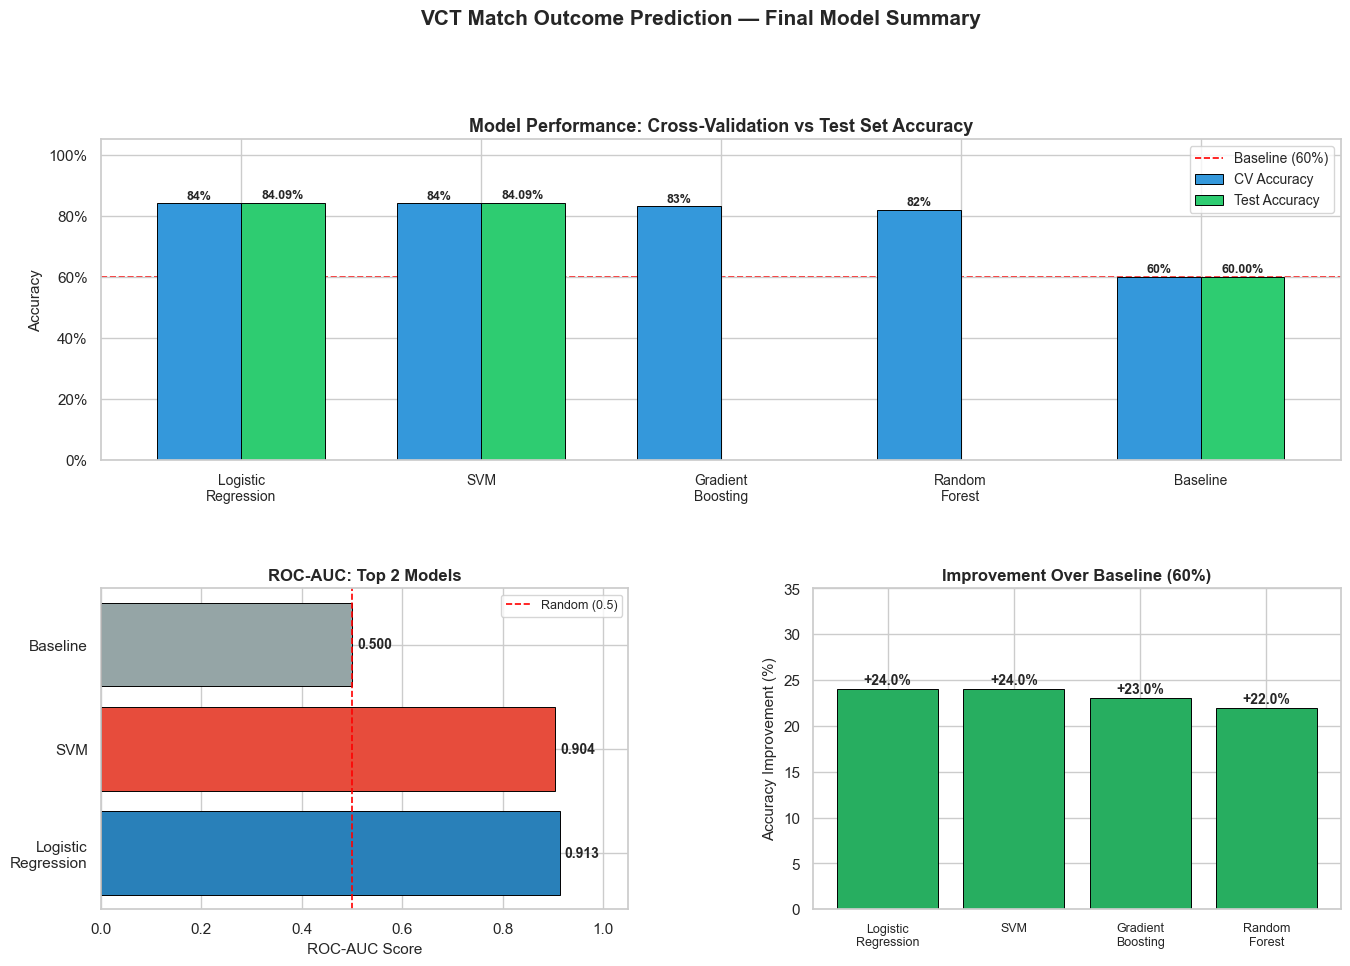

✅ Final model summary plot saved!


In [140]:
# All 4 model results compiled 
model_names = ['Logistic\nRegression', 'SVM', 'Gradient\nBoosting', 'Random\nForest', 'Baseline']

cv_scores    = [lr_grid.best_score_, svm_grid.best_score_,
                gbt_grid.best_score_, rf_grid.best_score_, baseline_acc]

test_scores  = [test_results['Logistic Regression']['accuracy'],
                test_results['SVM']['accuracy'],
                None, None, baseline_acc]

auc_scores   = [test_results['Logistic Regression']['auc'],
                test_results['SVM']['auc'],
                None, None, 0.5]

fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.4, wspace=0.35)

# ── Plot 1: CV vs Test Accuracy bar chart ─────────────────────────────
ax1 = fig.add_subplot(gs[0, :])   # spans full top row
x   = np.arange(len(model_names))
w   = 0.35

bars_cv   = ax1.bar(x - w/2, cv_scores, w,
                    label='CV Accuracy', color='#3498DB',
                    edgecolor='black', linewidth=0.7)
bars_test = ax1.bar(x + w/2,
                    [s if s is not None else 0 for s in test_scores], w,
                    label='Test Accuracy', color='#2ECC71',
                    edgecolor='black', linewidth=0.7)

# Hatch the bars with no test score
for i, s in enumerate(test_scores):
    if s is None:
        bars_test[i].set_hatch('//')
        bars_test[i].set_alpha(0.3)

# Value labels
for bar in bars_cv:
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{bar.get_height():.0%}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
for i, bar in enumerate(bars_test):
    if test_scores[i] is not None:
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.2%}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.axhline(baseline_acc, color='red', linestyle='--',
            linewidth=1.2, label=f'Baseline ({baseline_acc:.0%})', zorder=0)
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, fontsize=10)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Model Performance: Cross-Validation vs Test Set Accuracy',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# ── Plot 2: ROC-AUC scores ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

auc_models  = ['Logistic\nRegression', 'SVM', 'Baseline']
auc_vals    = [test_results['Logistic Regression']['auc'],
               test_results['SVM']['auc'], 0.5]
auc_colors  = ['#2980B9', '#E74C3C', '#95A5A6']

bars_auc = ax2.barh(auc_models, auc_vals, color=auc_colors,
                    edgecolor='black', linewidth=0.7)
ax2.axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='Random (0.5)')
ax2.set_xlim(0, 1.05)
ax2.set_xlabel('ROC-AUC Score', fontsize=11)
ax2.set_title('ROC-AUC: Top 2 Models', fontsize=12, fontweight='bold')
for bar, val in zip(bars_auc, auc_vals):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)

# ── Plot 3: Improvement over baseline ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

improvements = [(s - baseline_acc) * 100 for s in cv_scores[:-1]]
imp_colors   = ['#27AE60' if i > 20 else '#F39C12' for i in improvements]
imp_labels   = ['Logistic\nRegression', 'SVM', 'Gradient\nBoosting', 'Random\nForest']

bars_imp = ax3.bar(imp_labels, improvements, color=imp_colors,
                   edgecolor='black', linewidth=0.7)
for bar, val in zip(bars_imp, improvements):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'+{val:.1f}%', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

ax3.set_ylabel('Accuracy Improvement (%)', fontsize=11)
ax3.set_title('Improvement Over Baseline (60%)', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 35)
ax3.tick_params(axis='x', labelsize=9)

plt.suptitle('VCT Match Outcome Prediction — Final Model Summary',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('final_model_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final model summary plot saved!")